<a href="https://colab.research.google.com/github/mobarakol/tutorial_notebooks/blob/main/PathVQA_GPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q evaluate bert_score rouge_score --upgrade torchao

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.2 MB/s eta 0:00:00


data/validation-00000-of-00003-90a5518d2(…):   0%|          | 0.00/41.3M [00:00<?, ?B/s]

data/validation-00001-of-00003-cbfe947a3(…):   0%|          | 0.00/45.7M [00:00<?, ?B/s]

data/validation-00002-of-00003-9ec816895(…):   0%|          | 0.00/64.7M [00:00<?, ?B/s]

Generating validation split: 0 examples [00:00, ? examples/s]

samplesize: 6259
dict_keys(['image', 'question', 'answer'])
image reso;ution: (205, 315, 4)


Text(0.5, 1.0, 'Q: what is acute viral hepatitis characterized by?\nA: predominantly lymphocytic infiltrate')

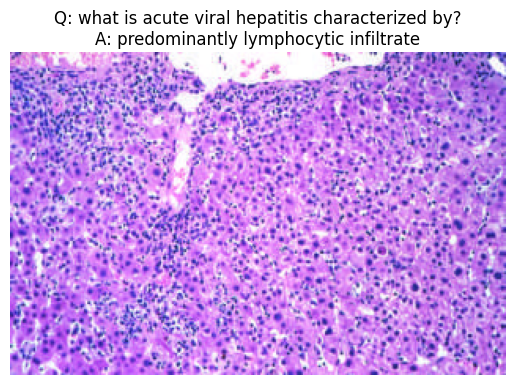

In [2]:
from datasets import load_dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
plt.axis('off')

pathvqa_valid = load_dataset("parquet", data_files={"validation": "hf://datasets/flaviagiammarino/path-vqa/data/validation-*.parquet"}, split="validation")
print('samplesize:', len(pathvqa_valid))
idx=3
print(pathvqa_valid[idx].keys())
print('image reso;ution:', np.array(pathvqa_valid[idx]['image']).shape)
plt.imshow(pathvqa_valid[idx]['image'])
plt.title(f'Q: {pathvqa_valid[idx]['question']}\nA: {pathvqa_valid[idx]['answer']}', fontsize=12)


#Prepare Dataloader

split: train = 5007 and test=1252
Sample size: Training: 5007 validation: 1252
image resolution: torch.Size([3, 224, 224])


Text(0.5, 1.0, 'Q: what is present?\nA: pituitary')

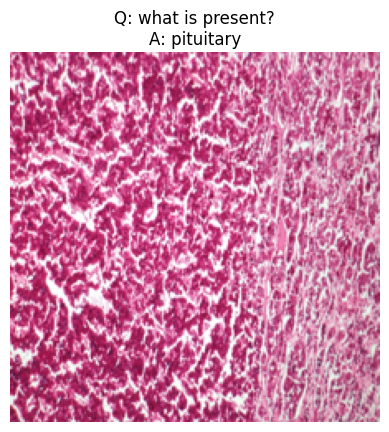

In [3]:
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader


class PathVQADataset(Dataset):
    def __init__(self, hf_dataset):
        """
        hf_dataset: HuggingFace dataset (already loaded split)
        """

        self.dataset = hf_dataset

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        # --- Image ---
        # HF dataset already provides PIL image
        raw_image = sample["image"].convert('RGB')
        img = self.transform(raw_image)

        # --- Question & Answer ---
        question = sample["question"]
        answer = sample["answer"]

        return img, question, answer


split_dataset = pathvqa_valid.train_test_split(test_size=0.2, seed=42)

train_data = split_dataset["train"]
val_data   = split_dataset["test"]
print(f'split: train = {len(train_data)} and test={len(val_data)}')

train_dataset = PathVQADataset(train_data)
val_dataset   = PathVQADataset(val_data)
print('Sample size: Training:', len(train_dataset), 'validation:', len(val_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)


img, question, answer = train_dataset[0]
print('image resolution:', img.size())
plt.axis('OFF')
plt.imshow(img.permute(1,2,0))
plt.title(f'Q: {question}\nA: {answer}', fontsize=12)

#Calculate Max Length

In [17]:
from tqdm import tqdm
from transformers import GPT2Tokenizer

# init tokenizer and model
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

def compute_max_length(dataset, tokenizer):
    max_len = 0

    for sample in dataset:
        question = sample["question"]
        answer = sample["answer"]

        text = f"Question: {question} Answer: {answer}"

        tokens = tokenizer(
            text,
            add_special_tokens=False
        )["input_ids"]

        if len(tokens) > max_len:
            max_len = len(tokens)

    return max_len

max_len = compute_max_length(pathvqa_valid, tokenizer)
print("Max token length:", max_len)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Max token length: 68


#Model Architecture

In [5]:
import math
import torch
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MedVQA(nn.Module):
    def __init__(self, peft_config=None):
        super(MedVQA, self).__init__()

        # visual encoder
        model_name = "google/vit-base-patch16-224-in21k"
        self.visual_encoder = ViTModel.from_pretrained(model_name)

        # Freeze all parameters in visual encoder
        for param in self.visual_encoder.parameters():
            param.requires_grad = False

        # tokenizer
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.tokenizer.pad_token = self.tokenizer.eos_token  # end of string

        # text encoder
        self.text_encoder = BlipTextModel.from_pretrained("Salesforce/blip-vqa-base")

        # modifying blip embedding size to fit with GPT-2
        original_weights = self.text_encoder.embeddings.word_embeddings.weight.data
        new_vocab_size = len(self.tokenizer)
        embedding_dim = self.text_encoder.embeddings.word_embeddings.embedding_dim
        new_embeddings = nn.Embedding(new_vocab_size, embedding_dim)
        original_vocab_size = original_weights.shape[0]
        new_embeddings.weight.data[:original_vocab_size] = original_weights
        self.text_encoder.embeddings.word_embeddings = new_embeddings

        # gpt2 decoder
        gpt = GPT2LMHeadModel.from_pretrained('gpt2')
        self.gpt = get_peft_model(gpt, peft_config)
        self.gpt.print_trainable_parameters()  # Verify trainable MoRA parameters

    def forward(self, image, qa_inputs_ids, qa_att_mask):
        # visual encoder
        image = image.to(device)
        image_embeds = self.visual_encoder(image).last_hidden_state
        image_atts = torch.ones(image_embeds.size()[:-1], dtype=torch.long).to(image.device)

        # multimodal encoder
        text_output = self.text_encoder(input_ids=qa_inputs_ids,
                                        attention_mask=qa_att_mask,
                                        encoder_hidden_states=image_embeds,
                                        encoder_attention_mask=image_atts,
                                        return_dict=True)
        text_embeds = text_output.last_hidden_state

        # text decoder
        gpt_output = self.gpt(inputs_embeds=text_embeds,
                              encoder_attention_mask=qa_att_mask)
        return gpt_output.logits

#Model Training

In [8]:
import os
import torch
import argparse
import torch.utils.data
import numpy as np
import random

from torch import nn
from torch.utils.data import DataLoader
from transformers import GPT2Tokenizer

import evaluate
from nltk.translate.bleu_score import corpus_bleu
from peft import  TaskType, LoraConfig

import warnings
warnings.filterwarnings('ignore')

def adjust_learning_rate(optimizer, shrink_factor):
    print("\nDECAYING learning rate.")
    for param_group in optimizer.param_groups:
        param_group['lr'] = param_group['lr'] * shrink_factor
    print("The new learning rate is %f\n" % (optimizer.param_groups[0]['lr'],))

def train(args, train_dataloader, model, criterion, optimizer, epoch, tokenizer, device):
    model.train()
    total_loss = []

    for i, (images, questions, answers) in enumerate(train_dataloader, 0):
        # prepare prompts
        qa_prompt = [f'Question: {q}\nAnswer: {a}' for q, a in zip(questions, answers)]
        qa_prompt_inputs = tokenizer(qa_prompt, truncation=True, padding="max_length", max_length=int(args.seq_length), return_tensors="pt")

        # get labels
        labels = qa_prompt_inputs['input_ids'].clone()
        labels = labels.to(device)

        # for labels, mask question tokens and padding tokens
        for idx, q in enumerate(questions):
            q_prompt = f"Question: {q}\nAnswer: "
            q_length = len(tokenizer(q_prompt)["input_ids"]) - 1

            labels[idx, :q_length] = -100  # mask question
            eos_mask = (labels[idx] == tokenizer.eos_token_id)  # get all EOS position
            if eos_mask.sum() > 1:  # if more than 1 EOS
                first_eos_pos = eos_mask.nonzero()[0].item()  # get first EOS position
                labels[idx, (first_eos_pos+1):] = -100  # mask paddings, left one EOS

        # get logits and labels
        logits = model(
                image=images.to(device),
                qa_inputs_ids=qa_prompt_inputs['input_ids'].to(device),
                qa_att_mask=qa_prompt_inputs['attention_mask'].to(device)
        )

        # get shifted logits and labels
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()

        # compute loss
        shift_logits = shift_logits.view(-1, shift_logits.size(-1))
        shift_labels = shift_labels.view(-1)
        loss = criterion(shift_logits, shift_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss.append(loss.item())
        if i%50 == 0:
            print("Training - Epoch: {}/{}, Iteration: {}/{}, AVG Training Loss: {:.6f}".format(epoch, args.epochs, i, len(train_dataloader), np.array(total_loss).mean()))


def validate(args, val_loader, model, criterion, epoch, tokenizer, device):
    total_loss = []
    model.eval()
    with torch.no_grad():
        for i, (images, questions, answers) in enumerate(val_loader, 0):
            # prepare prompts
            qa_prompt = [f'Question: {q}\nAnswer: {a}' for q, a in zip(questions, answers)]
            qa_prompt_inputs = tokenizer(qa_prompt, truncation=True, padding="max_length", max_length=int(args.seq_length), return_tensors="pt")

            # get labels
            labels = qa_prompt_inputs['input_ids'].clone()
            labels = labels.to(device)

            # for labels, mask question tokens and padding tokens
            answer_starts = []
            answer_ends = []
            for idx, q in enumerate(questions):
                q_prompt = f"Question: {q}\nAnswer: "
                q_length = len(tokenizer(q_prompt)["input_ids"]) - 1
                answer_starts.append(q_length+1)

                labels[idx, :q_length] = -100  # mask question
                eos_mask = (labels[idx] == tokenizer.eos_token_id)  # get all EOS position
                if eos_mask.sum() > 1:  # if more than 1 EOS
                    first_eos_pos = eos_mask.nonzero()[0].item()  # get first EOS position
                    labels[idx, (first_eos_pos+1):] = -100  # mask paddings, left one EOS
                    answer_ends.append(first_eos_pos)

            # get logits and labels
            logits = model(
                image=images.to(device),
                qa_inputs_ids=qa_prompt_inputs['input_ids'].to(device),
                qa_att_mask=qa_prompt_inputs['attention_mask'].to(device)
            )

            # get shifted logits and labels
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()

            # compute loss
            shift_logits = shift_logits.view(-1, shift_logits.size(-1))
            shift_labels = shift_labels.view(-1)
            loss = criterion(shift_logits, shift_labels)
            total_loss.append(loss.item())

    return np.array(total_loss).mean()


def seed_everything(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)


def get_arg():
    parser = argparse.ArgumentParser(description='VisualQuestionAnswerGeneration')
    # Training parameters
    parser.add_argument('--epochs',         type=int,   default=10,   help='number of epochs to train for')
    parser.add_argument('--batch_size',     type=int,   default=24,   help='batch size')
    parser.add_argument('--workers',        type=int,   default=8,    help='for data-loading')
    parser.add_argument('--random_seed',    type=int,   default=42,   help='random seed')
    parser.add_argument('--seq_length',     type=int,   default=68,   help='sequence length for question and answer')
    parser.add_argument('--dropout', type=float, default=0.1, help='dropout')

    parser.add_argument('--dataset',        default='endo',  help='endo / pit')
    parser.add_argument('--lr',             type=float, default=0.0000002,  help='0.0000001, 0.00000005')
    parser.add_argument('--checkpoint_dir', default='checkpoints/',  help='path to checkpoint')

    args = parser.parse_args([])
    return args


if __name__ == '__main__':

    args = get_arg()
    seed_everything(args.random_seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f'Batch size: {args.batch_size}')
    print(f'Learning rate: {args.lr}')
    print(f'Random seed: {args.random_seed}')
    print(f'Sequence length: {args.seq_length}')

    os.makedirs(args.checkpoint_dir, exist_ok = True)
    start_epoch = 1
    epochs_since_improvement = 0
    best_val_loss = float('inf')

    print(f'Dataset: {args.dataset}')
    train_dataloader = None
    val_dataloader = None


    train_dataset = PathVQADataset(train_data)
    val_dataset   = PathVQADataset(val_data)
    print('Sample size: Training:', len(train_dataset), 'validation:', len(val_dataset))

    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

    print('Sample size: Training:', len(train_dataset), 'validation:', len(val_dataset))

    # init tokenizer and model
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["c_attn", "c_proj"]
    )

    model = MedVQA(peft_config=lora_config)
    model = model.to(device)

    pytorch_total_params = sum(p.numel() for p in model.parameters())
    print('model params: ', pytorch_total_params)

    # init optimizer and criterion
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    criterion = nn.CrossEntropyLoss(ignore_index=-100).to(device)

    # train and validation
    print('Start training.')
    for epoch in range(start_epoch, args.epochs+1):
        if epochs_since_improvement > 0 and epochs_since_improvement % 5 == 0:
            adjust_learning_rate(optimizer, 0.8)

        # train
        train(args, train_dataloader=train_dataloader, model=model, criterion=criterion, optimizer=optimizer,
              epoch=epoch, tokenizer=tokenizer, device=device)
        # validation
        val_loss = validate(args, val_loader=val_dataloader, model=model, criterion=criterion,
                            epoch=epoch, tokenizer=tokenizer, device=device)

        if val_loss < best_val_loss:  # save model with better validation loss
            epochs_since_improvement = 0
            best_val_loss = val_loss
            save_dir = f'{args.checkpoint_dir}/best_model_mini.pth'
            torch.save(model.state_dict(), save_dir)
            model.tokenizer.save_pretrained(args.checkpoint_dir)
            print('Best validation loss, model saved.')
        else:
            epochs_since_improvement += 1
            print("\nEpochs since last improvement: %d\n" % (epochs_since_improvement,))
    print('End training.')

Batch size: 24
Learning rate: 2e-07
Random seed: 42
Sequence length: 68
Dataset: endo
Sample size: Training: 5007 validation: 1252
Sample size: Training: 5007 validation: 1252


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights: 0it [00:00, ?it/s]

BlipTextModel LOAD REPORT from: Salesforce/blip-vqa-base
Key                                                                             | Status     | 
--------------------------------------------------------------------------------+------------+-
vision_model.encoder.layers.{0...11}.layer_norm2.weight                         | UNEXPECTED | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias                           | UNEXPECTED | 
text_encoder.encoder.layer.{0...11}.crossattention.output.LayerNorm.bias        | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.output.LayerNorm.weight                | UNEXPECTED | 
text_encoder.encoder.layer.{0...11}.crossattention.self.query.weight            | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.intermediate.dense.weight              | UNEXPECTED | 
text_encoder.encoder.layer.{0...11}.attention.self.value.weight                 | UNEXPECTED | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight                            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 811,008 || all params: 125,250,816 || trainable%: 0.6475
model params:  364644096
Start training.
Training - Epoch: 1/10, Iteration: 0/157, AVG Training Loss: 9.611221
Training - Epoch: 1/10, Iteration: 50/157, AVG Training Loss: 9.106791
Training - Epoch: 1/10, Iteration: 100/157, AVG Training Loss: 8.851170
Training - Epoch: 1/10, Iteration: 150/157, AVG Training Loss: 8.614571
Best validation loss, model saved.
Training - Epoch: 2/10, Iteration: 0/157, AVG Training Loss: 8.147153
Training - Epoch: 2/10, Iteration: 50/157, AVG Training Loss: 7.829076
Training - Epoch: 2/10, Iteration: 100/157, AVG Training Loss: 7.591584
Training - Epoch: 2/10, Iteration: 150/157, AVG Training Loss: 7.415140
Best validation loss, model saved.
Training - Epoch: 3/10, Iteration: 0/157, AVG Training Loss: 7.189941
Training - Epoch: 3/10, Iteration: 50/157, AVG Training Loss: 6.869825
Training - Epoch: 3/10, Iteration: 100/157, AVG Training Loss: 6.778300
Training - Epoch: 3/10, Iterati

#Inference: few samples

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights: 0it [00:00, ?it/s]

BlipTextModel LOAD REPORT from: Salesforce/blip-vqa-base
Key                                                                             | Status     | 
--------------------------------------------------------------------------------+------------+-
vision_model.encoder.layers.{0...11}.layer_norm2.weight                         | UNEXPECTED | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias                           | UNEXPECTED | 
text_encoder.encoder.layer.{0...11}.crossattention.output.LayerNorm.bias        | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.output.LayerNorm.weight                | UNEXPECTED | 
text_encoder.encoder.layer.{0...11}.crossattention.self.query.weight            | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.intermediate.dense.weight              | UNEXPECTED | 
text_encoder.encoder.layer.{0...11}.attention.self.value.weight                 | UNEXPECTED | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight                            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 811,008 || all params: 125,250,816 || trainable%: 0.6475
Sample size: valid: 1252


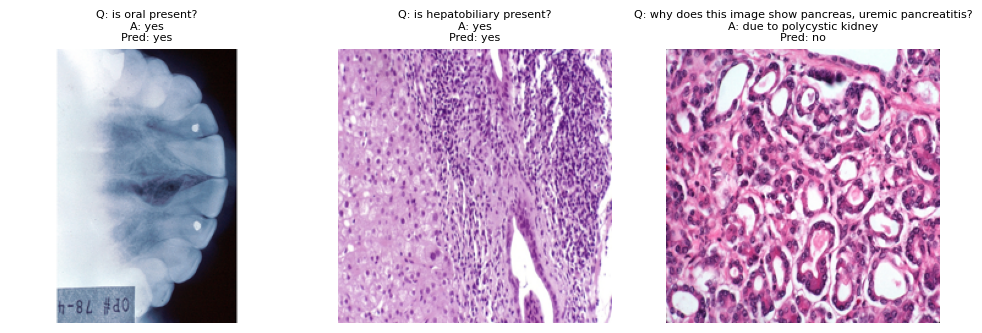

In [11]:
from tqdm import tqdm
import evaluate

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model
from peft import  TaskType, LoraConfig
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

def greedy_search_single(image, question, model, tokenizer, max_length, device):
    model.eval()
    with torch.no_grad():
        # Prepare prompt and tokenize
        prompt_text = f"Question: {question}\nAnswer:"
        inputs = tokenizer(prompt_text, return_tensors="pt", add_special_tokens=False)
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)

        # Pad to max_length
        padded_input_ids = torch.zeros((1, max_length), dtype=torch.long, device=device)
        padded_attention_mask = torch.zeros((1, max_length), dtype=torch.long, device=device)
        seq_len = input_ids.size(1)
        padded_input_ids[:, :seq_len] = input_ids
        padded_attention_mask[:, :seq_len] = attention_mask

        valid_length = seq_len
        generated_ids = []

        image = image.unsqueeze(0).to(device)  # Add batch dim

        for _ in range(max_length - seq_len):
            logits = model(
                image=image,
                qa_inputs_ids=padded_input_ids[:, :valid_length],
                qa_att_mask=padded_attention_mask[:, :valid_length]
            )

            last_logits = logits[0, valid_length - 1]  # shape: [vocab_size]
            next_token_id = torch.argmax(F.softmax(last_logits, dim=-1), dim=-1)

            if next_token_id.item() == tokenizer.eos_token_id:
                break

            padded_input_ids[0, valid_length] = next_token_id
            padded_attention_mask[0, valid_length] = 1
            valid_length += 1
            generated_ids.append(next_token_id.item())

        # Decode generated tokens
        answer = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
        return answer


def inference_few_samples(sample_indices = [4, 5, 7]):
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["c_attn", "c_proj"]
    )

    model = MedVQA(peft_config=lora_config)
    # save_dir = f'{args.checkpoint_dir}/best_model_sds.pth'
    save_dir = f'/content/checkpoints/best_model_mini.pth'
    model.load_state_dict(torch.load(save_dir, map_location=device))
    model.to(device)
    model.eval()

    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    val_dataset   = PathVQADataset(val_data)
    print('Sample size: valid:', len(val_dataset))

    # Create subplots
    fig, axes = plt.subplots(1, len(sample_indices), figsize=(12, 5))  # 1 row, 3 columns
    for ax, idx in zip(axes, sample_indices):
        img, question, answer_gt = val_dataset[idx]

        # Run inference
        pred_answer = greedy_search_single(img, question, model, tokenizer, max_length=32, device=device)
        img = img.permute(1, 2, 0)  # Convert from [C, H, W] to [H, W, C] for imshow
        ax.imshow(img)
        ax.set_title(f'Q: {question}\nA: {answer_gt}\nPred: {pred_answer}', fontsize=8)
        ax.axis('off')


inference_few_samples(sample_indices = [40, 8, 50])
